<a href="https://colab.research.google.com/github/engEugene/ml-formative2-assignment/blob/main/PCA_Formative_1%5BGroup_50%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)

# Github - https://github.com/engEugene/ml-formative2-assignment

This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [25]:
# Import libraries (numpy and matplotlib only)
import csv
import time
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Libraries loaded successfully.")


NumPy version: 2.0.2
Libraries loaded successfully.


In [26]:
# Load data from CSV using the built-in csv module (no pandas)
DATA_PATH = "ObservationData_lavlqce.csv"

with open(DATA_PATH, newline="", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header = next(reader)
    raw_rows = [row for row in reader]

print("Original data shape:", len(raw_rows), "rows x", len(header), "columns")
print("Column names:", header[:5], "...")
print("First row (preview):", raw_rows[0][:4], "...")


Original data shape: 2322 rows x 31 columns
Column names: ['Country', 'Year', 'Real per Capita GDP Growth Rate (annual %)', 'Real GDP growth (annual %)', 'Gross domestic product, (constant prices US$)'] ...
First row (preview): ['Malawi', '1980', '', ''] ...


In [27]:
# Data handling: missing values, non-numeric encoding
MISSING_TOKEN = ""

def to_float(value):
    value = value.strip()
    if value == "" or value.upper() == "NAN":
        return np.nan
    return float(value)

# Separate column types
country_idx = header.index("Country")
year_idx = header.index("Year")
feature_names = [h for i, h in enumerate(header) if i not in (country_idx, year_idx)]

countries = sorted({row[country_idx] for row in raw_rows})
country_to_code = {name: i for i, name in enumerate(countries)}

# Build numeric matrix: label-encode Country, keep Year, keep economic indicators
n_rows = len(raw_rows)
n_features = len(feature_names) + 2  # Country code + Year + numeric indicators
data = np.full((n_rows, n_features), np.nan)

col_names = ["Country_code", "Year"] + feature_names

numeric_col_indices = [i for i, h in enumerate(header) if h not in ("Country", "Year")]

for r, row in enumerate(raw_rows):
    data[r, 0] = country_to_code[row[country_idx]]
    data[r, 1] = to_float(row[year_idx])
    for j, col_idx in enumerate(numeric_col_indices):
        data[r, j + 2] = to_float(row[col_idx])

# Report missing values before imputation
missing_per_col = np.isnan(data).sum(axis=0)
print("Missing values per column (top 5):")
top_missing = np.argsort(missing_per_col)[::-1][:5]
for idx in top_missing:
    print(f"  {col_names[idx]}: {int(missing_per_col[idx])} missing")

# Mean imputation column by column (numpy only)
col_means = np.nanmean(data, axis=0)
inds = np.where(np.isnan(data))
data[inds] = np.take(col_means, inds[1])

print(f"\nEncoded {len(countries)} African countries as integers (0..{len(countries)-1}).")
print("Processed data shape:", data.shape)
print("Feature names:", col_names[:6], "...")


Missing values per column (top 5):
  Central government, total revenue and grants  (% of GDP): 164 missing
  Central government, total revenue and grants  (Current US $): 164 missing
  Gross capital formation, Public sector (% GDP): 163 missing
  Gross capital formation, Private sector (% GDP): 163 missing
  Gross capital formation, Private sector  (current US$): 163 missing

Encoded 54 African countries as integers (0..53).
Processed data shape: (2322, 31)
Feature names: ['Country_code', 'Year', 'Real per Capita GDP Growth Rate (annual %)', 'Real GDP growth (annual %)', 'Gross domestic product, (constant prices US$)', 'Gross domestic product, current prices (current US$)'] ...


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

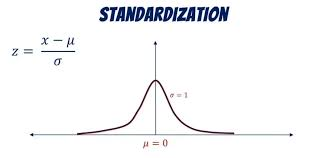


In [28]:
# Step 1: Standardize the data (numpy only)
x = data
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
std = np.where(std == 0, 1, std)
standardized_data = (x - mean) / std

print("Standardized data shape:", standardized_data.shape)
standardized_data[:5]


Standardized data shape: (2322, 31)


array([[ 1.60402581e-01, -1.69222822e+00, -3.36864107e-16,
        -6.51182270e-16, -3.84049558e-01, -3.61993377e-01,
        -3.69004683e-01, -3.67435578e-01, -3.56018977e-01,
        -3.93954876e-01, -4.01589949e-01, -3.28884796e-01,
        -4.13026264e-01, -4.34324636e-01, -1.36824738e+00,
        -6.08789416e-01, -1.23212277e+00, -6.79197138e-01,
        -8.70387057e-01,  2.58650974e-02, -7.45425147e-01,
        -7.13137509e-01,  2.08721623e-01, -3.93192205e-01,
        -3.82111768e-01, -3.22816307e-01, -7.40001362e-01,
        -4.37535750e-01,  6.29245116e-02, -3.77554192e-01,
         1.25080377e-15],
       [ 1.60402581e-01, -1.61164593e+00, -1.78287028e+00,
        -1.75654968e+00, -3.89263989e-01, -3.61992670e-01,
        -3.69295658e-01, -3.69626149e-01, -3.55899472e-01,
        -4.01000037e-01, -4.01401233e-01, -3.43946836e-01,
        -4.12311927e-01, -4.40781806e-01, -1.39340534e+00,
        -7.17801738e-01, -1.22258627e+00, -1.04890016e+00,
        -8.63401933e-01, -4.64

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.


In [29]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)


Covariance matrix shape: (31, 31)


**Why compute a covariance matrix?** (max 5 lines)

1. PCA needs the covariance matrix to find directions of maximum joint variability across economic indicators (GDP, trade, fiscal balance, inflation, etc.).
2. It captures how features move together (e.g., consumption and GDP often co-vary), which eigenvectors then summarize into fewer components.
3. After standardization, the covariance matrix puts all indicators on equal scale so no single unit (US dollars vs. percentages) dominates the analysis.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.


In [30]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues shape: (31,)
Eigenvectors shape: (31, 31)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order.


In [31]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted eigenvalues (first 5):", sorted_eigenvalues[:5])
print("Sorted eigenvectors shape:", sorted_eigenvectors.shape)


Sorted eigenvalues (first 5): [11.11410687  4.00627681  2.85342477  2.16959018  1.57129543]
Sorted eigenvectors shape: (31, 31)


### Task 2: Explained Variance and Dynamic Component Selection
Calculate the percentage of variance explained by each principal component and choose *k* based on cumulative explained variance.


Explained variance (first 10 PCs):
  PC1: 35.84%  (cumulative: 35.84%)
  PC2: 12.92%  (cumulative: 48.75%)
  PC3: 9.20%  (cumulative: 57.96%)
  PC4: 7.00%  (cumulative: 64.95%)
  PC5: 5.07%  (cumulative: 70.02%)
  PC6: 4.64%  (cumulative: 74.65%)
  PC7: 4.06%  (cumulative: 78.72%)
  PC8: 3.40%  (cumulative: 82.12%)
  PC9: 3.04%  (cumulative: 85.16%)
  PC10: 2.65%  (cumulative: 87.81%)

Selected k = 11 components (>= 90% variance threshold)
Variance retained: 90.17%


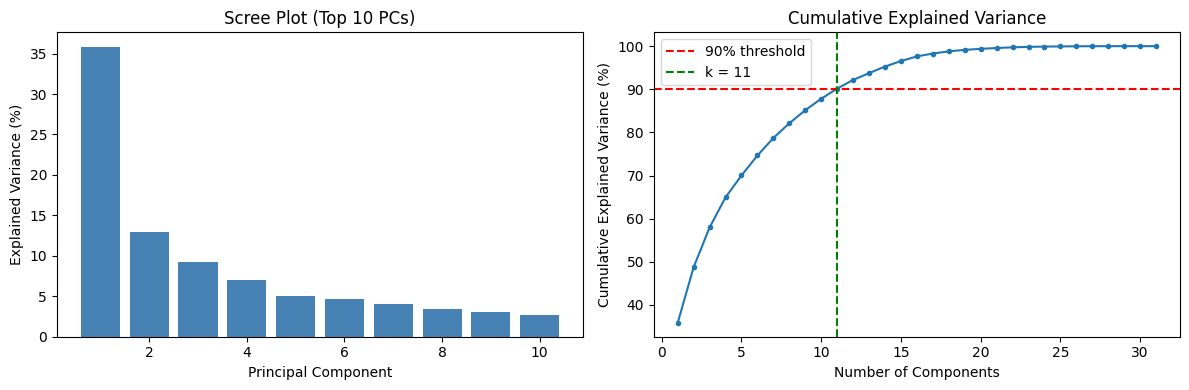

In [32]:
# Task 2: Explained variance and dynamic selection
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance (first 10 PCs):")
for i in range(10):
    print(f"  PC{i+1}: {explained_variance_ratio[i]*100:.2f}%  (cumulative: {cumulative_variance[i]*100:.2f}%)")

# Select smallest k that retains at least 90% of total variance
VARIANCE_THRESHOLD = 0.90
num_components = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1)
variance_retained = cumulative_variance[num_components - 1]

print(f"\nSelected k = {num_components} components (>= {VARIANCE_THRESHOLD*100:.0f}% variance threshold)")
print(f"Variance retained: {variance_retained * 100:.2f}%")

# Scree / cumulative variance plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, 11), explained_variance_ratio[:10] * 100, color="steelblue")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance (%)")
ax[0].set_title("Scree Plot (Top 10 PCs)")

ax[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker="o", markersize=3)
ax[1].axhline(VARIANCE_THRESHOLD * 100, color="red", linestyle="--", label=f"{VARIANCE_THRESHOLD*100:.0f}% threshold")
ax[1].axvline(num_components, color="green", linestyle="--", label=f"k = {num_components}")
ax[1].set_xlabel("Number of Components")
ax[1].set_ylabel("Cumulative Explained Variance (%)")
ax[1].set_title("Cumulative Explained Variance")
ax[1].legend()
plt.tight_layout()
plt.show()


### Step 6: Project Data onto Principal Components


In [33]:
# Step 6: Project onto selected principal components
principal_components = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ principal_components

print(f"Projected shape: {reduced_data.shape}")
reduced_data[:5]


Projected shape: (2322, 11)


array([[ 1.47774525, -1.92472116, -0.66845002,  1.00241825, -1.11877376,
         0.55268108,  1.17021363,  0.5464292 , -0.07772815, -0.69835341,
         0.65040629],
       [ 1.48608742, -2.70815061,  0.09940939,  2.72361746, -0.21515616,
        -0.71787684,  0.66287154,  0.36092687, -0.11477406, -0.71938535,
         0.57708591],
       [ 1.45270205, -2.40272553, -0.79842807,  1.3310173 , -1.05260653,
         0.36767952,  0.4817581 ,  0.32552366, -0.17576044, -0.63990964,
         0.44162529],
       [ 1.44900078, -2.44878712, -1.01225226,  0.91119977, -1.24959887,
         0.47029726,  0.47478329,  0.23091815, -0.08519444, -0.50775238,
         0.44701517],
       [ 1.49271874, -2.87551288, -1.14696938,  0.97844062, -0.53572006,
         0.5274987 ,  0.8802963 ,  0.29614624, -0.38651973, -0.10935936,
         0.40510718]])

### Step 7: Output the Reduced Data


In [34]:
# Step 7: Output the Reduced Data
print(f"Reduced Data Shape: {reduced_data.shape}")
print(f"Original features: {standardized_data.shape[1]} -> Reduced components: {num_components}")
reduced_data[:5]


Reduced Data Shape: (2322, 11)
Original features: 31 -> Reduced components: 11


array([[ 1.47774525, -1.92472116, -0.66845002,  1.00241825, -1.11877376,
         0.55268108,  1.17021363,  0.5464292 , -0.07772815, -0.69835341,
         0.65040629],
       [ 1.48608742, -2.70815061,  0.09940939,  2.72361746, -0.21515616,
        -0.71787684,  0.66287154,  0.36092687, -0.11477406, -0.71938535,
         0.57708591],
       [ 1.45270205, -2.40272553, -0.79842807,  1.3310173 , -1.05260653,
         0.36767952,  0.4817581 ,  0.32552366, -0.17576044, -0.63990964,
         0.44162529],
       [ 1.44900078, -2.44878712, -1.01225226,  0.91119977, -1.24959887,
         0.47029726,  0.47478329,  0.23091815, -0.08519444, -0.50775238,
         0.44701517],
       [ 1.49271874, -2.87551288, -1.14696938,  0.97844062, -0.53572006,
         0.5274987 ,  0.8802963 ,  0.29614624, -0.38651973, -0.10935936,
         0.40510718]])

### Step 8: Visualize Before and After PCA


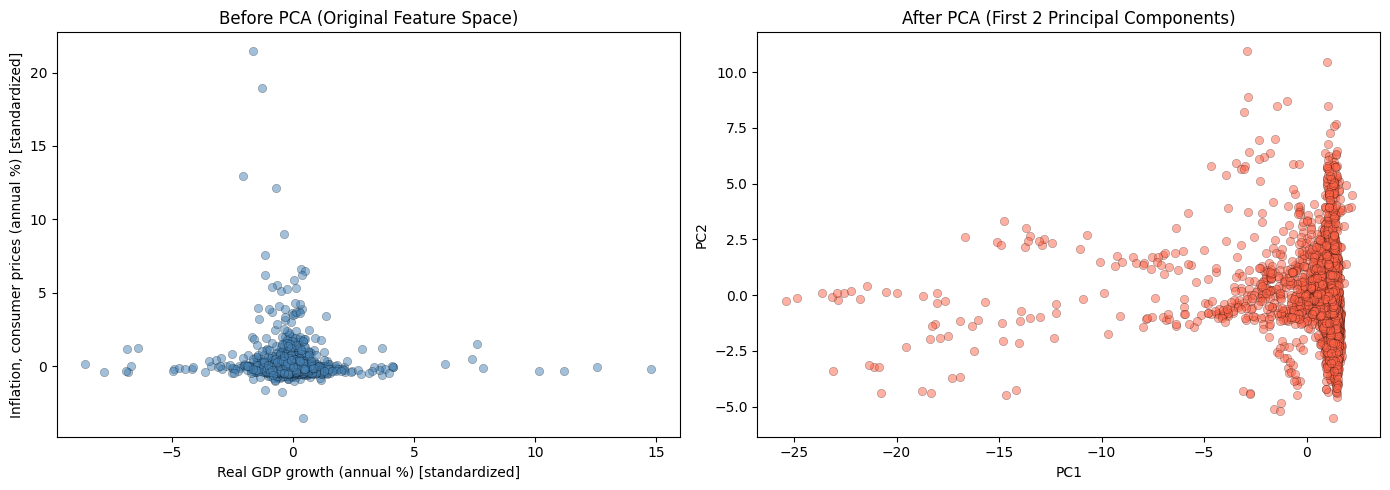

Variance in PC1: 11.109320431513822
Variance in PC2: 4.004551457605211


In [35]:
# Step 8: Visualize Before and After PCA
# Use two meaningful original features for the 'before' plot
feat_x = col_names.index("Real GDP growth (annual %)")
feat_y = col_names.index("Inflation, consumer prices (annual %)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    standardized_data[:, feat_x], standardized_data[:, feat_y],
    alpha=0.5, color="steelblue", edgecolors="k", linewidths=0.3,
)
axes[0].set_title("Before PCA (Original Feature Space)")
axes[0].set_xlabel("Real GDP growth (annual %) [standardized]")
axes[0].set_ylabel("Inflation, consumer prices (annual %) [standardized]")

axes[1].scatter(
    reduced_data[:, 0], reduced_data[:, 1],
    alpha=0.5, color="tomato", edgecolors="k", linewidths=0.3,
)
axes[1].set_title("After PCA (First 2 Principal Components)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

# Verify PC1 has higher spread than PC2
print("Variance in PC1:", np.var(reduced_data[:, 0]))
print("Variance in PC2:", np.var(reduced_data[:, 1]))


### Task 3: Performance Benchmarking
Compare a naive loop-based projection with the vectorized NumPy implementation on the full dataset.


In [36]:
# Task 3: Benchmark naive vs vectorized PCA projection
components = sorted_eigenvectors[:, :num_components]
data_matrix = standardized_data
n_runs = 5

# Naive double loop
start = time.perf_counter()
for _ in range(n_runs):
    naive_result = np.zeros((data_matrix.shape[0], components.shape[1]))
    for i in range(data_matrix.shape[0]):
        for j in range(components.shape[1]):
            naive_result[i, j] = np.dot(data_matrix[i], components[:, j])
naive_time = (time.perf_counter() - start) / n_runs

# Vectorized matrix multiplication
start = time.perf_counter()
for _ in range(n_runs):
    fast_result = data_matrix @ components
fast_time = (time.perf_counter() - start) / n_runs

print(f"Naive loop projection:      {naive_time:.4f} s")
print(f"Vectorized (@) projection:  {fast_time:.4f} s")
print(f"Speedup: {naive_time / fast_time:.1f}x")
print("Results match:", np.allclose(naive_result, fast_result))


Naive loop projection:      0.0494 s
Vectorized (@) projection:  0.0003 s
Speedup: 185.4x
Results match: True


### Written Responses

**1. Interpret the before/after PCA visual**

The left plot uses two raw indicators GDP growth and inflation after standardization. Countries facing high inflation and low growth (e.g. crisis years) sit in different regions than stable growth years. The right plot shows the same 2,322 country year records projected onto PC1 and PC2. The cloud is rotated so that PC1 (horizontal spread) captures the direction of greatest overall variance across all 32 encoded features, not just those two indicators.

**2. Why we selected *k* components (tradeoffs)**

We set *k* to the smallest number of principal components whose cumulative explained variance reaches 90%. This is a common balance: we keep most of the dataset’s macroeconomic information while cutting dimensionality from 32 to *k*. The tradeoff is interpretability vs compression each component we drop removes a slice of variance (see the scree plot), so models become lighter but country specific patterns in trade, fiscal policy, or investment may be blended into broader “size of economy” trends.

**3. Information lost for this economic-activity dataset**

When we reduce dimensions, we no longer have one axis per indicator. Separate signals such as government fiscal balance, household consumption share, export dependence, and capital formation are combined into composite PCs. For policymakers studying **economic activity**, this means we can compare countries on broad macro profiles but lose direct readouts of, say, whether fiscal deficits or import surges drive a country’s position unless we examine eigenvector loadings for each PC.
